This data is of people in Mexico, Peru and Colombia. the data includes age, height, weight. all this data shows obesity level/underweight. Essentially, this dataset aims to demonstrate what lifestylee habits lead to either overweight condition or underweight condition. This could be used to have people be made aware of what habit heavily contributes to either being overweight or underweight.

In [394]:
import plotly.graph_objects as go
import pandas as pd
import seaborn as sns
import numpy as np

In [396]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [398]:
#DISPLAY HEAD OF DATASET
print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

In [400]:
unique_classes = df['NObeyesdad'].unique()
palette = sns.color_palette("Dark2", len(unique_classes)).as_hex()

In [402]:
color_map = dict(zip(unique_classes, palette))
df['Color'] = df['NObeyesdad'].map(color_map)

In [404]:
fig = go.Figure(data=[go.Scatter3d(
    x=df['Height'],
    y=df['Weight'],
    z=df['Age'],
    mode='markers',
    marker=dict(
        size=6,
        color=df['Color'],
        opacity=0.85
    ),
    text=df['NObeyesdad']
)])

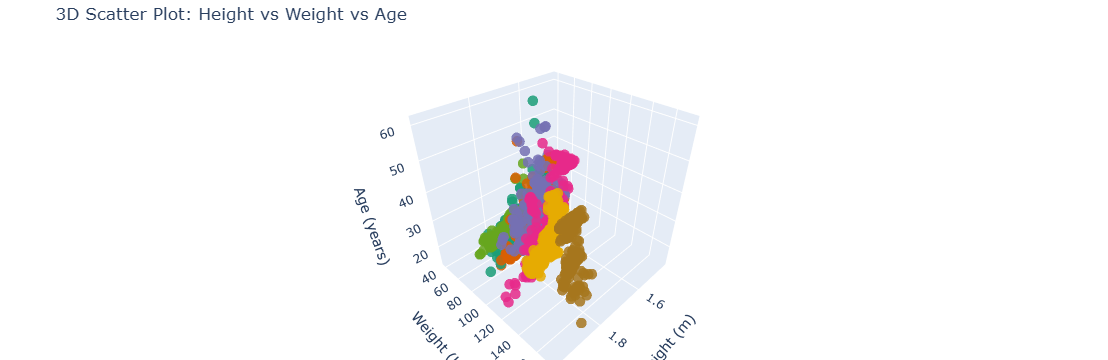

In [406]:
fig.update_layout(
    title="3D Scatter Plot: Height vs Weight vs Age",
    scene=dict(
        xaxis_title='Height (m)',
        yaxis_title='Weight (kg)',
        zaxis_title='Age (years)'
    ),
    legend_title_text='Obesity Class',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

This scatterplot shows the relation of obesity classification using age weight and height as factors.

In [331]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

#IMPORT DATASET
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

#NUMERIC CONVERSION
calc_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}


In [333]:

df['CALC_num'] = df['CALC'].map(calc_map)

#BINS VALUES INTO CATEGORIES
df['FAF_bin'] = pd.cut(df['FAF'], bins=[-0.1, 1, 2, 3, 4, 5], labels=[0, 1, 2, 3, 4])

#GROUPS BY CALC_NUM & FAF_BIN AND COUNTS NUM OF ROWS
grouped = df.groupby(['CALC_num', 'FAF_bin']).size().reset_index(name='count')


C:\Users\saul7\AppData\Local\Temp\ipykernel_20764\3742630802.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [335]:
 
#CONVERTS VALUES TO FLOATS TO USE AS X AXIS
x = grouped['CALC_num'].astype(float)
#CONVERTS VALUES INTO INTS TO USE AS Y AXIS
y = grouped['FAF_bin'].astype(int)
#BASE HEIGHT OF BARS
z = np.zeros(len(grouped))  
dx = dy = 0.4
dz = grouped['count']


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')



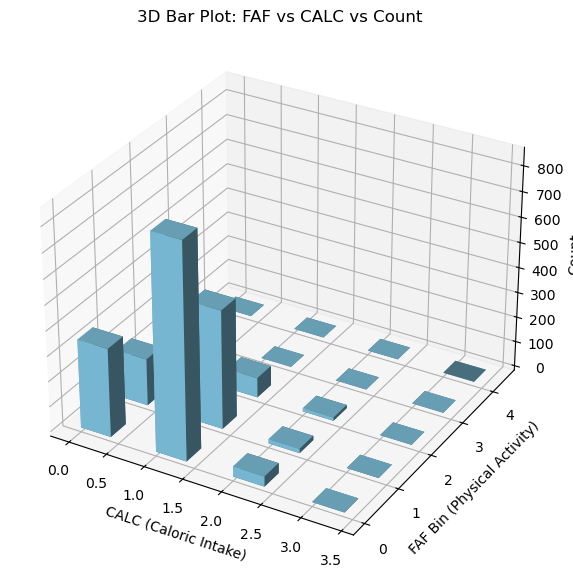

In [337]:
ax.bar3d(x, y, z, dx, dy, dz, shade=True, color='skyblue')


ax.set_xlabel('CALC (Caloric Intake)')
ax.set_ylabel('FAF Bin (Physical Activity)')
ax.set_zlabel('Count')
ax.set_title('3D Bar Plot: FAF vs CALC vs Count')
plt.savefig("SAULRODRIGUEZ-TAPIA_3D Bar Plot: FAF vs CALC vs Count.png", dpi=300, bbox_inches='tight')
plt.show()

In [339]:
#IMPORT DATASET
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [341]:
#TARGET CLASS
target_class = "Obesity_Type_I"

In [343]:
#AGE AND WEIGHT BINS
age_bins = np.arange(10, 70, 5)
weight_bins = np.arange(30, 150, 5)

df['Age_bin'] = pd.cut(df['Age'], bins=age_bins)
df['Weight_bin'] = pd.cut(df['Weight'], bins=weight_bins)

In [345]:
grouped = df.groupby(['Age_bin', 'Weight_bin'])
total_counts = grouped.size().unstack().fillna(0)
target_counts = grouped.apply(lambda x: (x['NObeyesdad'] == target_class).sum()).unstack().fillna(0)


C:\Users\saul7\AppData\Local\Temp\ipykernel_20764\1880881776.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\saul7\AppData\Local\Temp\ipykernel_20764\1880881776.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [347]:
# PERCENT FREQUENCY OF PEOPLE IN EACH BIN
proportion = (target_counts / total_counts.replace(0, np.nan)).fillna(0)

age_centers = [interval.mid for interval in proportion.index.categories]
weight_centers = [interval.mid for interval in proportion.columns.categories]

In [349]:
#MESHGRID
X, Y = np.meshgrid(weight_centers, age_centers)
Z = proportion.values

# PLOT
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='inferno', edgecolor='k', linewidth=0.5)

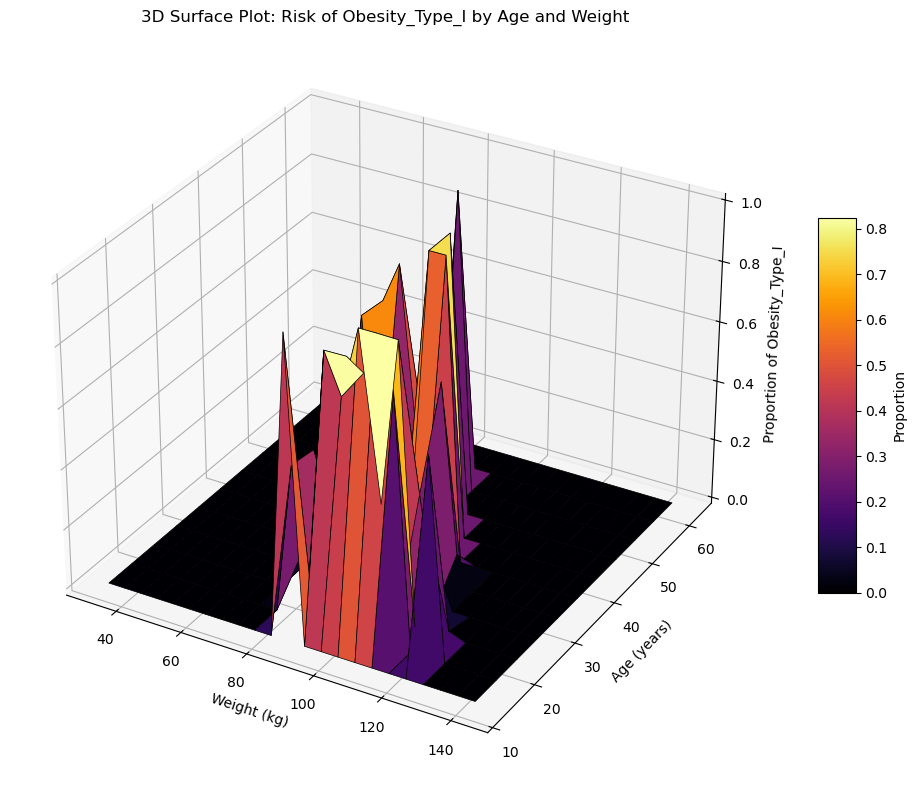

In [351]:
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Age (years)')
ax.set_zlabel(f'Proportion of {target_class}')
ax.set_title(f'3D Surface Plot: Risk of {target_class} by Age and Weight')

fig.colorbar(surf, shrink=0.5, aspect=10, label='Proportion')
plt.tight_layout()
plt.savefig("SAULRODRIGUEZ-TAPIA_3D Surface Plot: Risk of Obseity_Type_I by Age and Weight.png", dpi=300, bbox_inches='tight')

plt.show()

This surface plot shows when type I obesity is most common, the peaks are when type I are most common, the flat areas are where theres little to no occurance of obesity type I the gradient represents a smooth transition in the level of risk

In [354]:
#IMPORT DATASET
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [356]:
# REMOVE ROWS WITH MISSING DATA
df = df.dropna(subset=['CH2O', 'Age', 'NObeyesdad'])

In [358]:
#GET OBESITY CLASSES
classes = df['NObeyesdad'].unique()
classes.sort()

In [360]:
#PREP BOXPLOT
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

In [362]:
for i, obesity_class in enumerate(classes):
    subset = df[df['NObeyesdad'] == obesity_class]
    
    # Create box "illusion" using scatter points
    x = subset['CH2O']
    y = subset['Age']
    z = np.full_like(x, i)  # fake depth by index

    ax.scatter(x, y, z, alpha=0.5, label=obesity_class)

In [364]:
# LABELS FOR AXIS
ax.set_xlabel('CH2O (Water Consumption)')
ax.set_ylabel('Age (years)')
ax.set_zlabel('Obesity Class Index')
ax.set_title('CH2O vs Age vs Obesity Class (Simulated 3D Box Plot)')

Text(0.5, 0.92, 'CH2O vs Age vs Obesity Class (Simulated 3D Box Plot)')

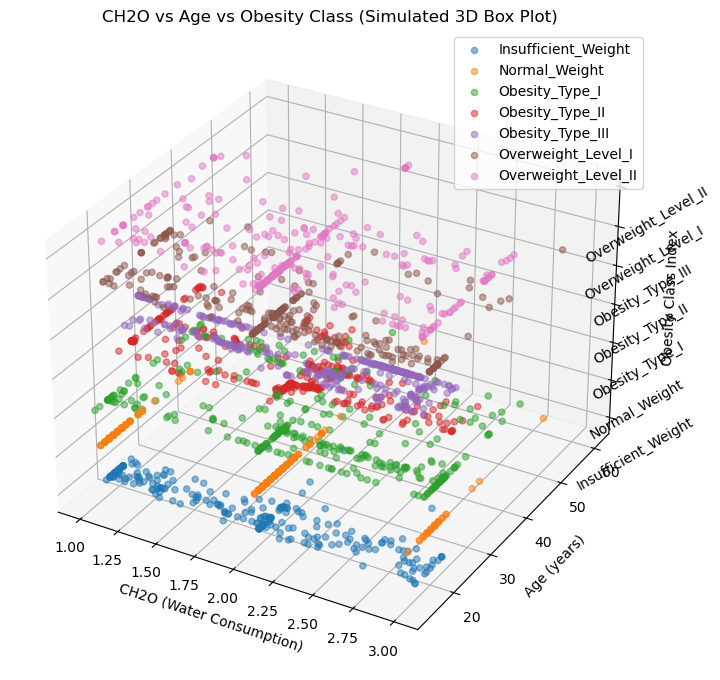

In [366]:
ax.set_zticks(np.arange(len(classes)))
ax.set_zticklabels(classes, rotation=30)

plt.legend()
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.savefig("SAULRODRIGUEZ-TAPIA_CH2O vs Age vs Obesity Class (Simulated 3D Box Plot).png", dpi=300, bbox_inches='tight')

plt.show()

this demonstrates water consumption in different weight and age categories

In [369]:
#IMPORT DATASET
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [371]:
#REMOVE MISSING VALUES
df = df.dropna(subset=['NObeyesdad', 'SMOKE', 'MTRANS'])

In [373]:
#GET CATEGORIES
obesity_classes = sorted(df['NObeyesdad'].unique())
smoke_statuses = sorted(df['SMOKE'].unique())
mobility_modes = sorted(df['MTRANS'].unique())

In [375]:
#PREP PLOT
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

dx = dy = 0.2
bar_spacing = 0.25 
smoke_gap = (len(mobility_modes) + 1)

In [377]:
#COLOR FOR EACH TRANSPORTATION METHOD
colors = plt.cm.tab10(np.linspace(0, 1, len(mobility_modes)))
color_map = dict(zip(mobility_modes, colors))

In [379]:
for i, obesity in enumerate(obesity_classes):
    for j, smoke in enumerate(smoke_statuses):
        for k, mobility in enumerate(mobility_modes):
           
            count = len(df[
                (df['NObeyesdad'] == obesity) &
                (df['SMOKE'] == smoke) &
                (df['MTRANS'] == mobility)
            ])
            xpos = i
            ypos = j + (k * bar_spacing)  
            zpos = 0
            ax.bar3d(xpos, ypos, zpos, dx, dy, count,
                     color=color_map[mobility],
                     edgecolor='k',
                     alpha=0.8,
                     label=mobility if i == 0 and j == 0 and k == 0 else "")

In [381]:
#AXES LABELS
ax.set_xlabel('Obesity Class')
ax.set_ylabel('Smoking Status + Mobility')
ax.set_zlabel('Count')
ax.set_title('3D Bar Chart: Obesity × Smoking × Mobility')

Text(0.5, 0.92, '3D Bar Chart: Obesity × Smoking × Mobility')

In [383]:
ax.set_xticks(np.arange(len(obesity_classes)))
ax.set_xticklabels(obesity_classes, rotation=45)

y_ticks = []
y_tick_labels = []

In [385]:
for j, smoke in enumerate(smoke_statuses):
   
    center = j * smoke_gap + (len(mobility_modes)-1)*bar_spacing/2
    y_ticks.append(center)
    y_tick_labels.append(smoke)

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels)

[Text(0.5, 0, 'no'), Text(6.5, -0.0843804389344028, 'yes')]

C:\Users\saul7\AppData\Local\Temp\ipykernel_20764\3356382828.py:1: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.



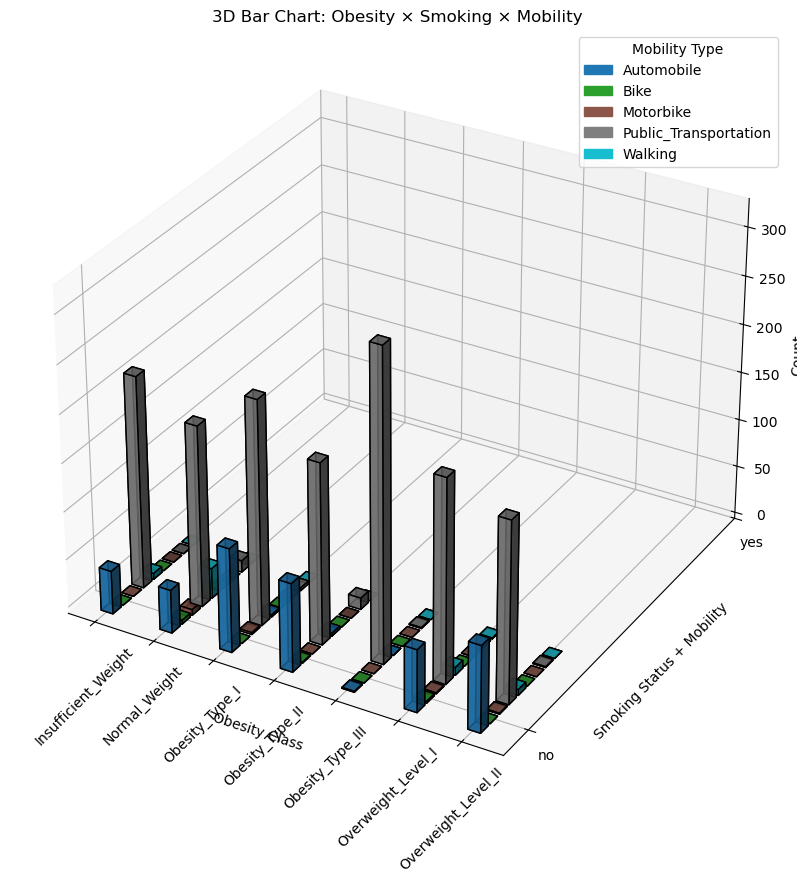

In [387]:
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[mob], edgecolor='k') for mob in mobility_modes]
ax.legend(handles, mobility_modes, title='Mobility Type', loc='upper right')

plt.tight_layout()
plt.savefig("SAULRODRIGUEZ-TAPIA_3D Bar Chart: Obesity × Smoking × Mobility.png", dpi=300, bbox_inches='tight')

plt.show()

This bar plot shows the different categories of obesity, number of people, smoking status and transportation method. overall this graph shows that people who dont smoke and take public transportation are the ones that are usually obese with type III being the highest amount of people out of the other types